In [22]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [23]:
iris = load_iris()

X = iris.data
y = iris.target

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y #stratify=y makes sure the train and test sets have roughly the same proportion of each class
)

In [25]:
depths = [1, 2, 3, 4, 5, 6, 10, None]

train_scores = []
cv_scores = []

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    # Training accuracy
    model.fit(X_train, y_train)
    train_accuracy = model.score(X_train, y_train)
    train_scores.append(train_accuracy)

    # 5-fold cross-validation accuracy
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )
    cv_scores.append(scores.mean())

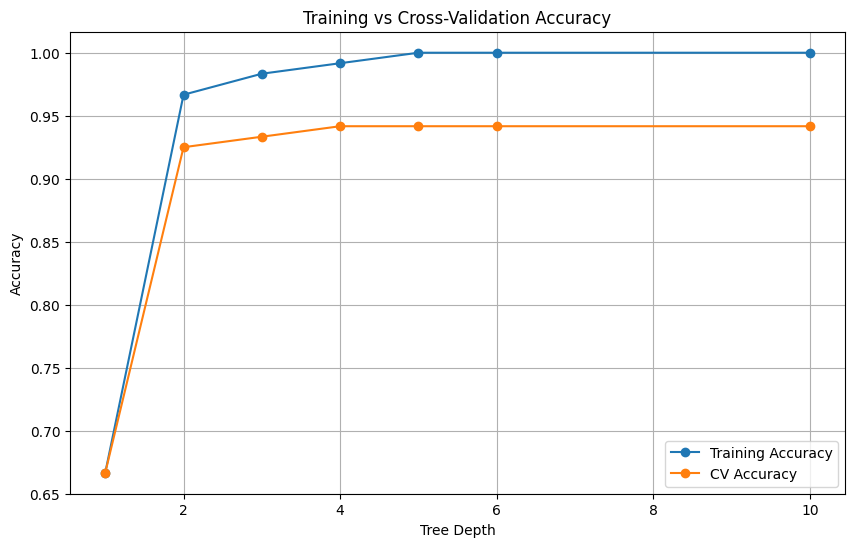

In [26]:
plt.figure(figsize=(10, 6))

plt.plot(depths[:-1], train_scores[:-1], marker="o", label="Training Accuracy")
plt.plot(depths[:-1], cv_scores[:-1], marker="o", label="CV Accuracy")

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Training vs Cross-Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

So tree depth 4 is good. After it CV accuracy doesnt improve.